In [1]:
!rm -rf /root/.config/Google

Mount Drive

In [2]:
import os
from google.colab import drive

# Ensure the mount point is clean before attempting to mount
if os.path.exists('/content/drive'):
    # Remove the directory entirely if it exists, as drive.mount will recreate it.
    !rm -rf /content/drive
    print("Removed existing /content/drive directory to ensure a clean mount point.")

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Import Lib

In [3]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Set Parameters

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 10
LR = 1e-4

DATA_PATH = "/content/drive/MyDrive/btp/data"
MODEL_SAVE_PATH = "/content/drive/MyDrive/btp"
IMG_SAVE_PATH = "/content/drive/MyDrive/btp/plots"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(IMG_SAVE_PATH, exist_ok=True)

Apply Preprocessing

In [5]:
def apply_clahe(image):
    image = np.array(image)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(enhanced)

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda x: apply_clahe(x)),
    transforms.ToTensor(),
])

Load data

In [6]:
dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform)
print("Classes:", dataset.classes)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

Classes: ['Normal', 'Stone']


select ResNet18 Model

In [7]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


In [8]:
def plot_metrics(train_losses, val_losses, val_accuracies):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.savefig(os.path.join(IMG_SAVE_PATH, "loss_curve.png"))
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(val_accuracies, label="Val Accuracy")
    plt.legend()
    plt.title("Validation Accuracy")
    plt.savefig(os.path.join(IMG_SAVE_PATH, "val_accuracy.png"))
    plt.show()

Train ResNet model

In [9]:
def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_losses, val_losses, val_accuracies = [], [], []
    best_acc = 0

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        preds_all, labels_all = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(labels_all, preds_all)

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, "best_resnet18_ksd.pth"))

        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, val_accuracies

Epoch 1/10 | Train Loss: 0.2842 | Val Loss: 0.1837 | Val Acc: 0.9385
Epoch 2/10 | Train Loss: 0.0883 | Val Loss: 0.2000 | Val Acc: 0.9385
Epoch 3/10 | Train Loss: 0.0315 | Val Loss: 0.1382 | Val Acc: 0.9623
Epoch 4/10 | Train Loss: 0.0244 | Val Loss: 0.0870 | Val Acc: 0.9762
Epoch 5/10 | Train Loss: 0.0133 | Val Loss: 0.1094 | Val Acc: 0.9762
Epoch 6/10 | Train Loss: 0.0179 | Val Loss: 0.1247 | Val Acc: 0.9702
Epoch 7/10 | Train Loss: 0.0192 | Val Loss: 0.1099 | Val Acc: 0.9722
Epoch 8/10 | Train Loss: 0.0119 | Val Loss: 0.1591 | Val Acc: 0.9643
Epoch 9/10 | Train Loss: 0.0088 | Val Loss: 0.0864 | Val Acc: 0.9643
Epoch 10/10 | Train Loss: 0.0067 | Val Loss: 0.1163 | Val Acc: 0.9623


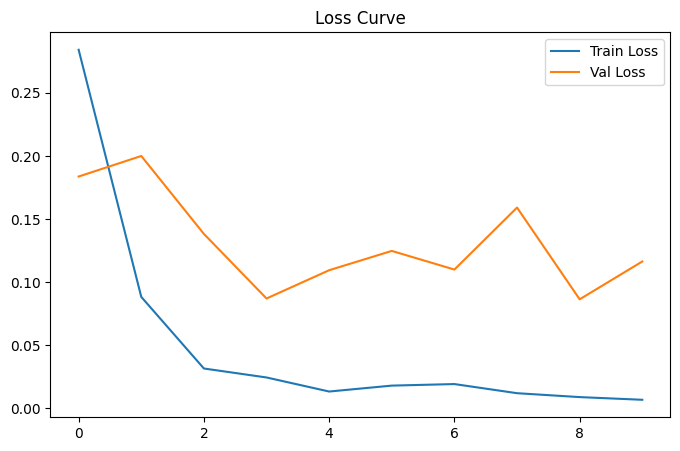

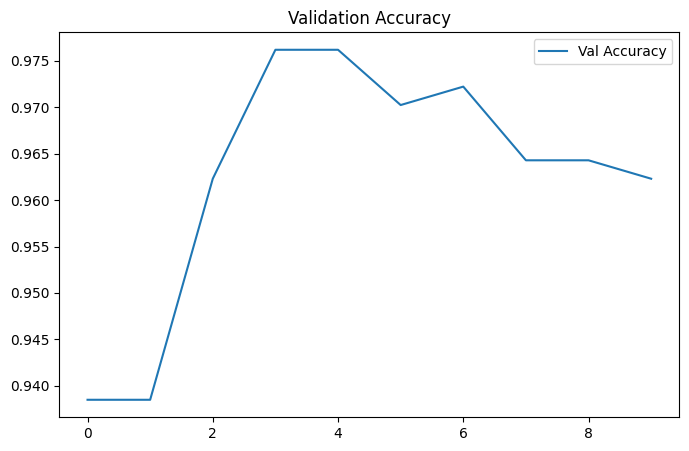

In [10]:
train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader)
plot_metrics(train_losses, val_losses, val_accuracies)

In [11]:
def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    print("Test Accuracy:", acc)

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred, target_names=dataset.classes))

Performance metrices

In [12]:
evaluate_model(model, test_loader)

Test Accuracy: 0.9703557312252964
Confusion Matrix:
 [[259  10]
 [  5 232]]
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97       269
       Stone       0.96      0.98      0.97       237

    accuracy                           0.97       506
   macro avg       0.97      0.97      0.97       506
weighted avg       0.97      0.97      0.97       506



Load Data for autoencoder


In [13]:
normal_indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
normal_subset = Subset(dataset, normal_indices)
auto_loader = DataLoader(normal_subset, batch_size=32, shuffle=True)

In [14]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Train Autoencoder

In [15]:
autoencoder = Autoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

auto_losses = []

for epoch in range(EPOCHS):
    autoencoder.train()
    total_loss = 0

    for images, _ in auto_loader:
        images = images.to(DEVICE)
        outputs = autoencoder(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(auto_loader)
    auto_losses.append(epoch_loss)
    print(f"AE Epoch {epoch+1}/{EPOCHS}: {epoch_loss:.4f}")

torch.save(autoencoder.state_dict(), os.path.join(MODEL_SAVE_PATH, "autoencoder_ksd.pth"))

AE Epoch 1/10: 0.0855
AE Epoch 2/10: 0.0080
AE Epoch 3/10: 0.0051
AE Epoch 4/10: 0.0034
AE Epoch 5/10: 0.0025
AE Epoch 6/10: 0.0021
AE Epoch 7/10: 0.0018
AE Epoch 8/10: 0.0017
AE Epoch 9/10: 0.0016
AE Epoch 10/10: 0.0015


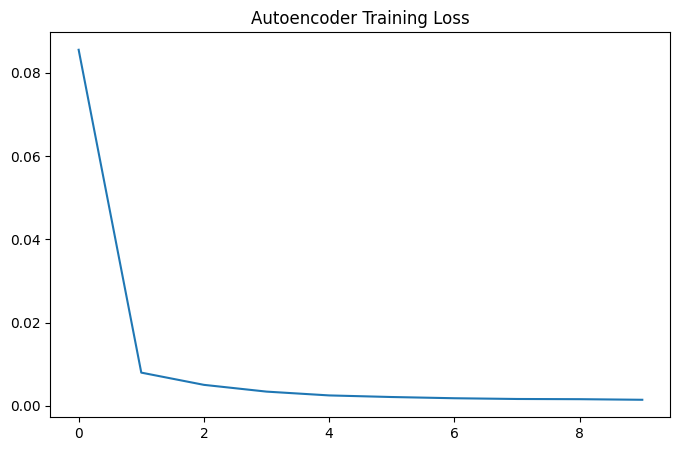

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(auto_losses)
plt.title("Autoencoder Training Loss")
plt.savefig(os.path.join(IMG_SAVE_PATH, "autoencoder_loss.png"))
plt.show()

In [17]:
def get_autoencoder_heatmap(model, image):
    model.eval()
    with torch.no_grad():
        output = model(image)

    error = (image - output).pow(2).squeeze().cpu().numpy()
    heatmap = error.mean(axis=0)

    # Normalize heatmap for display if it's not already
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap

In [18]:
sample_img, _ = dataset[random.randint(0, len(dataset)-1)]
sample_img = sample_img.unsqueeze(0).to(DEVICE)
get_autoencoder_heatmap(autoencoder, sample_img)

array([[1.77567333e-01, 3.38891670e-02, 9.28275101e-03, ...,
        4.97989682e-03, 1.43447826e-02, 1.16449505e-01],
       [3.72918509e-02, 2.76675401e-03, 1.46226701e-03, ...,
        5.56604718e-05, 6.25512621e-04, 2.28057019e-02],
       [1.57672502e-02, 3.64234741e-03, 3.54123709e-04, ...,
        4.45434154e-04, 7.08227337e-04, 2.29324847e-02],
       ...,
       [2.08616862e-03, 4.87784891e-05, 3.63524741e-05, ...,
        4.83721524e-05, 3.44997206e-05, 6.62732520e-04],
       [5.61468769e-03, 9.06568384e-05, 1.31128170e-03, ...,
        6.56468561e-04, 2.14490516e-04, 6.75765499e-02],
       [1.42105728e-01, 1.91524122e-02, 1.06002167e-02, ...,
        1.10577755e-02, 8.25379882e-03, 2.85851628e-01]], dtype=float32)

In [19]:
# Create input_tensor FIRST
idx = random.randint(0, len(dataset) - 1)
original_tensor, _ = dataset[idx]
input_tensor = original_tensor.unsqueeze(0).to(DEVICE)

# Get prediction
model.eval()
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_class].item()

class_name = dataset.classes[pred_class]
print(f"Prediction: {class_name} ({confidence*100:.2f}%)")

Prediction: Stone (99.98%)


Grad-cam


In [20]:
model.layer3

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(256, eps=1

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_image, class_idx=None):
        self.model.eval()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()
        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        cam = torch.sum(weights * activations, dim=1).squeeze()
        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().detach().numpy()

visualize stone, reconstructed , error heatmao and grad-cam

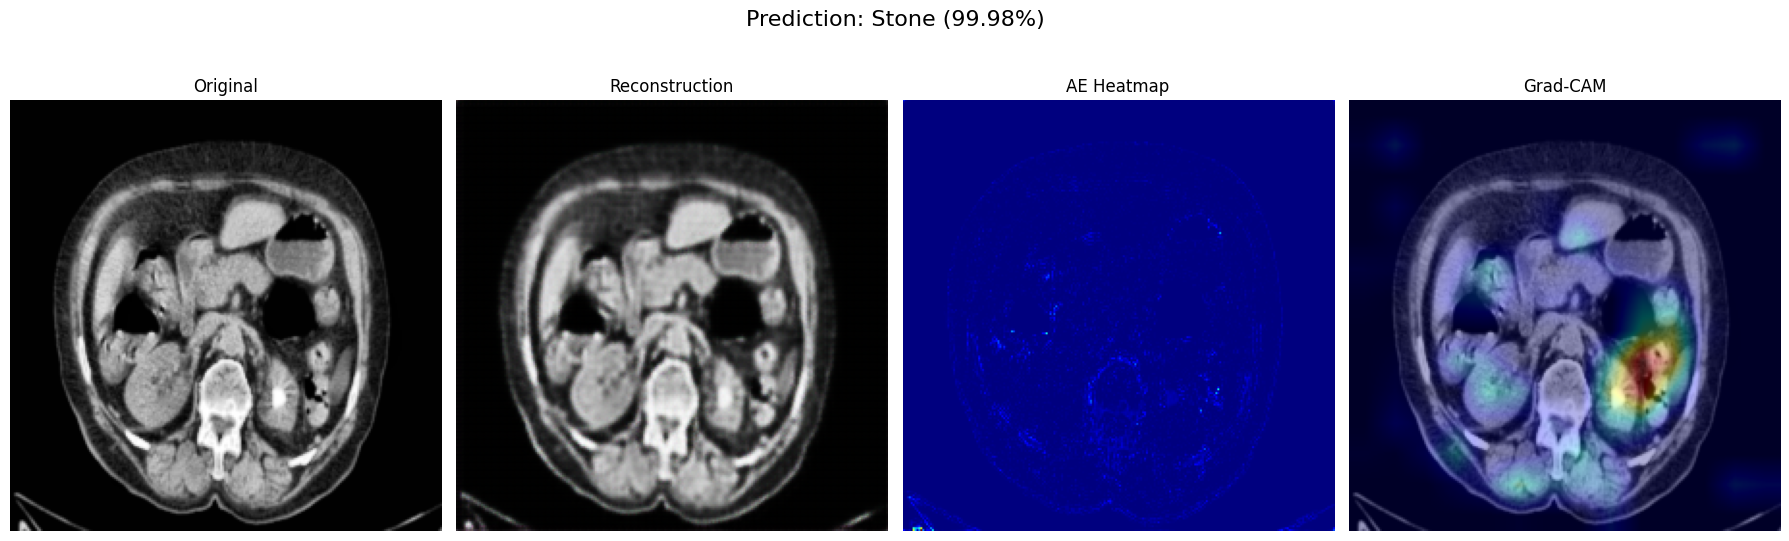

In [23]:
# Load trained autoencoder
autoencoder_weights_path = os.path.join(MODEL_SAVE_PATH, "autoencoder_ksd.pth")
autoencoder = Autoencoder().to(DEVICE)
autoencoder.load_state_dict(torch.load(autoencoder_weights_path))
autoencoder.eval()

# Find stone image
stone_indices = [i for i, (_, label) in enumerate(dataset) if label == 1]

if not stone_indices:
    print("No stone images found.")
else:
    idx = random.choice(stone_indices)
    original_tensor, _ = dataset[idx]
    input_tensor = original_tensor.unsqueeze(0).to(DEVICE)

    # Autoencoder
    with torch.no_grad():
        reconstructed = autoencoder(input_tensor)

    ae_heatmap = get_autoencoder_heatmap(autoencoder, input_tensor)

    # Grad-CAM
    gradcam = GradCAM(model, model.layer3)
    grad_heatmap = gradcam.generate(input_tensor, class_idx=1)

    # Convert images
    original_img = original_tensor.permute(1, 2, 0).cpu().numpy()
    original_img = (original_img - original_img.min()) / (original_img.max() - original_img.min() + 1e-8)

    reconstructed_img = reconstructed.squeeze().permute(1, 2, 0).cpu().numpy()
    reconstructed_img = (reconstructed_img - reconstructed_img.min()) / (reconstructed_img.max() - reconstructed_img.min() + 1e-8)

    grad_heatmap_resized = cv2.resize(grad_heatmap, (IMG_SIZE, IMG_SIZE))

    grad_overlay = cv2.applyColorMap(np.uint8(255 * grad_heatmap_resized), cv2.COLORMAP_JET)
    grad_overlay = grad_overlay / 255.0

    grad_overlay = grad_overlay * 0.3 + original_img * 0.7

    # Convert BGR → RGB for matplotlib
    grad_overlay = cv2.cvtColor((grad_overlay * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))
    fig.suptitle(f"Prediction: {class_name} ({confidence*100:.2f}%)", fontsize=16)

    axes[0].imshow(original_img)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(reconstructed_img)
    axes[1].set_title("Reconstruction")
    axes[1].axis('off')

    axes[2].imshow(ae_heatmap, cmap='jet')
    axes[2].set_title("AE Heatmap")
    axes[2].axis('off')

    axes[3].imshow(grad_overlay)
    axes[3].set_title("Grad-CAM")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()